In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

from FEX.models import fex
device = 'cuda' if torch.cuda.is_available() else 'cpu'

Using device: cuda


In [2]:
from generate_data import make_data, make_adjacency
timesteps=5000
adj_matrix = make_adjacency(100, 3)
timeseries, t_derivs = make_data(num_samples=5000, adjacency=adj_matrix, snr=30, coupling=0.8)

In [3]:
# print average degree
print(adj_matrix.sum() / adj_matrix.size(0))

tensor(2.9200)


In [5]:
dimx_fex = fex.CoupledFEX('depth_2_tree_config', 'depth_2_tree_config', 0, controller_epochs=200, controller_lr=0.005, finetune_epochs=20000, finetune_lr=1e-4, num_fex_epochs=120, self_lr=0.02, inter_lr=0.02, bfgs_epochs=20, bfgs_lr=1.0, poolsize=8, device=device, expression_threshold=0.1)
dimx_fex.fit(timeseries, t_derivs, adj_matrix, num_workers=5, finetune_bs=512)

Using 5 parallel processes for candidate evaluation.
Using device: cudaUsing device: cuda

Using device: cuda
Using device: cuda
Evaluating candidate 0 on GPU 0
Evaluating candidate 1 on GPU 0
Evaluating candidate 2 on GPU 0
Evaluating candidate 3 on GPU 0
Using device: cuda
Evaluating candidate 4 on GPU 0
Evaluating candidate 5 on GPU 0
Evaluating candidate 6 on GPU 0
Evaluating candidate 7 on GPU 0
Evaluating candidate 8 on GPU 0
Evaluating candidate 9 on GPU 0
Evaluation time for fex epoch: 0.09 seconds
Epoch 0 pmfs: [array([[0.36988494, 0.34790903, 0.28220603]], dtype=float32), array([[0.13314335, 0.15835908, 0.1611073 , 0.14425348, 0.14357038,
        0.1371645 , 0.12240186]], dtype=float32), array([[0.16285582, 0.15413064, 0.1524099 , 0.1613414 , 0.12071862,
        0.13045521, 0.11808839]], dtype=float32), array([[0.3439695 , 0.29276365, 0.36326683]], dtype=float32), array([[0.16342428, 0.13978046, 0.12931804, 0.13362   , 0.17139198,
        0.14157484, 0.12089039]], dtype=float

In [6]:
dimy_fex = fex.SingleFEX('depth_3_leaves_4_config', 1, num_finetune_epochs=5000, controller_epochs=200, num_fex_epochs=80, device=device)
dimy_fex.fit(timeseries, t_derivs, num_workers=5)

Using 5 parallel processes for candidate evaluation.
Using device: cudaUsing device: cudaUsing device: cudaUsing device: cuda


Using device: cuda

Evaluating candidate 0 on GPU 0
Evaluating candidate 2 on GPU 0
Evaluating candidate 1 on GPU 0
Evaluating candidate 3 on GPU 0
Evaluating candidate 4 on GPU 0
Evaluating candidate 5 on GPU 0
Evaluating candidate 6 on GPU 0
Evaluating candidate 7 on GPU 0
Evaluating candidate 8 on GPU 0
Evaluating candidate 9 on GPU 0
Evaluation time for fex epoch: 0.07 seconds
Epoch 0, pmfs: [array([[0.32793212, 0.34011585, 0.33195204]], dtype=float32), array([[0.31262282, 0.36951017, 0.317867  ]], dtype=float32), array([[0.32321948, 0.31199014, 0.36479038]], dtype=float32), array([[0.13285361, 0.16005681, 0.13655826, 0.13785519, 0.12819667,
        0.14343256, 0.16104689]], dtype=float32), array([[0.15120655, 0.15551606, 0.12410539, 0.1344088 , 0.14050977,
        0.14943841, 0.14481495]], dtype=float32), array([[0.12654153, 0.13315876, 0.14931743, 0.1586

In [7]:
dimz_fex = fex.SingleFEX('depth_3_leaves_4_config', 2, num_finetune_epochs=5000, num_fex_epochs=80, device=device)
dimz_fex.fit(timeseries, t_derivs, num_workers=5)

Using 5 parallel processes for candidate evaluation.
Using device: cudaUsing device: cudaUsing device: cuda


Using device: cuda
Using device: cuda
Evaluating candidate 0 on GPU 0
Evaluating candidate 1 on GPU 0
Evaluating candidate 2 on GPU 0
Evaluating candidate 3 on GPU 0
Evaluating candidate 4 on GPU 0
Evaluating candidate 5 on GPU 0
Evaluating candidate 6 on GPU 0
Evaluating candidate 7 on GPU 0
Evaluating candidate 8 on GPU 0
Evaluating candidate 9 on GPU 0
Evaluation time for fex epoch: 0.07 seconds
Epoch 0, pmfs: [array([[0.31637982, 0.33408773, 0.34953246]], dtype=float32), array([[0.3213284 , 0.3408859 , 0.33778566]], dtype=float32), array([[0.34586775, 0.34196427, 0.31216797]], dtype=float32), array([[0.13106464, 0.14408642, 0.16578895, 0.12302001, 0.14482476,
        0.14289202, 0.14832324]], dtype=float32), array([[0.14352928, 0.14386323, 0.13579156, 0.14854784, 0.15026055,
        0.129368  , 0.14863956]], dtype=float32), array([[0.14684878, 0.1447635 , 0.15548398, 0.1282

In [8]:
print(dimx_fex)
print(dimy_fex)
print(dimz_fex)

FEX(self_fex=-10.1155*x1 + 9.9804*x2 + 0.0112*x3 - 0.0148 
inter_fex=0.0014784*x1**2 - 0.004224*x1*x3 - 0.00167783*x1*x4 - 0.5116375*x1 + 0.00117666*x2*x4 - 0.08216144*x2 + 0.0047938*x3*x4 + 0.58076887*x4 + 0.02958483*x5 - 0.0346489)
FEX = -0.96002494*x1*x3 + 26.54698156*x1 + 0.02328669*x2*x3 - 0.64089384*x2 - 0.00507899*x3 + 0.13994804
FEX = -0.0173410000000001*x1**2 + 1.0167948*x1*x2 - 0.0044718*x1*x3 + 0.0124887*x1 - 0.01230836*x2**2 + 0.00382452*x2*x3 + 0.00326982000000001*x2 + 0.00439159*x3**2 - 2.76105287*x3 + 0.5622181


/tmp/ipykernel_384360/2798859293.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


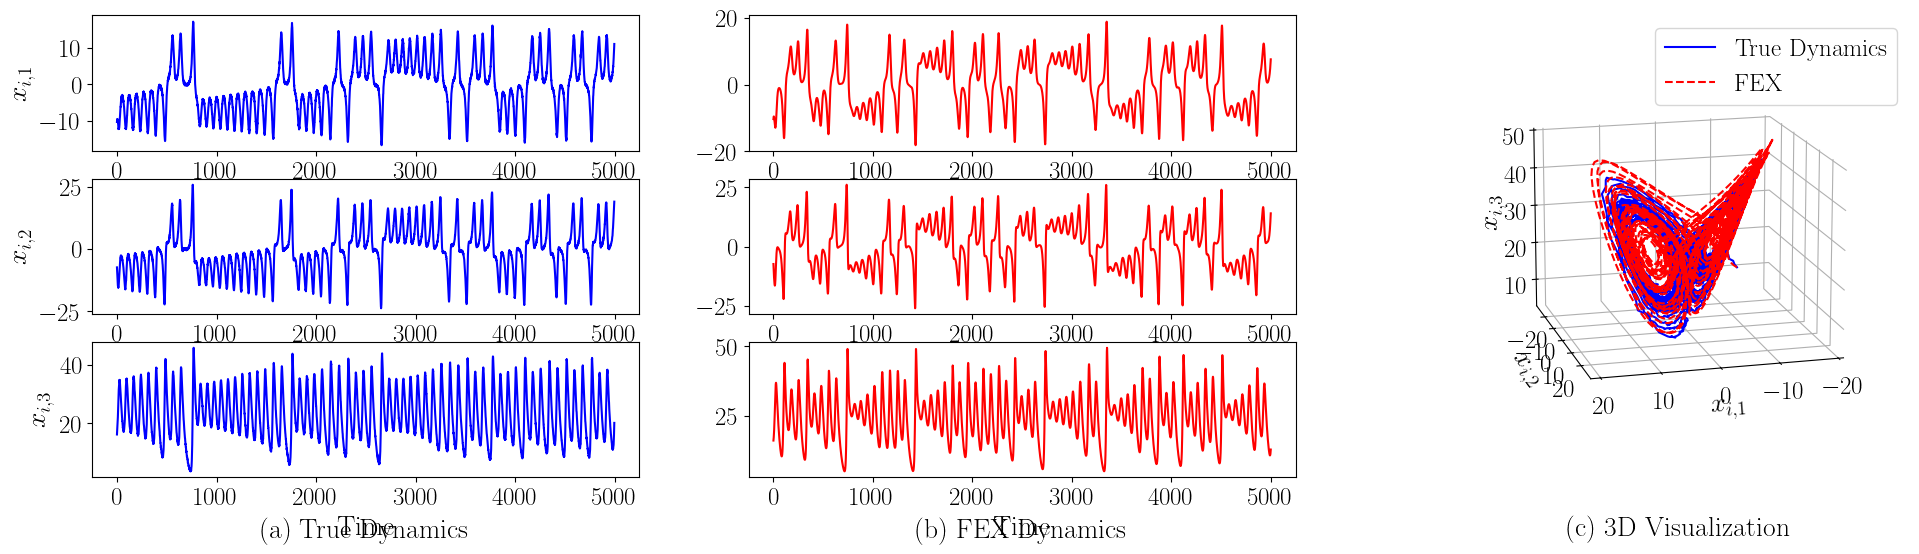

In [9]:
predicted_states = torch.zeros(timesteps + 1, timeseries.size(1), timeseries.size(2), device=device)
predicted_states[0] = timeseries[0]
dt = 0.01
with torch.no_grad():
    for t in range(timesteps):
        state = predicted_states[t]

        dx_dt = torch.cat([
            dimx_fex.predict(state, adj_matrix.to(device)), # dimx_fex.predict(state, adj_matrix),
            dimy_fex.predict(state),
            dimz_fex.predict(state)
        ], dim=-1)

        predicted_states[t+1] = state + dt * dx_dt

        if not torch.isfinite(predicted_states[t+1]).all():
            print(f"Non-finite state at timestep {t + 1}")
            break
        
from FEX.utils.plots import plot_dynamics

node = 80
fig = plot_dynamics(timeseries[:, node, 0].cpu(), timeseries[:, node, 1].cpu(), timeseries[:, node, 2].cpu(), predicted_states[:, node, :].cpu(), elev=15, azim=75)
fig.show()


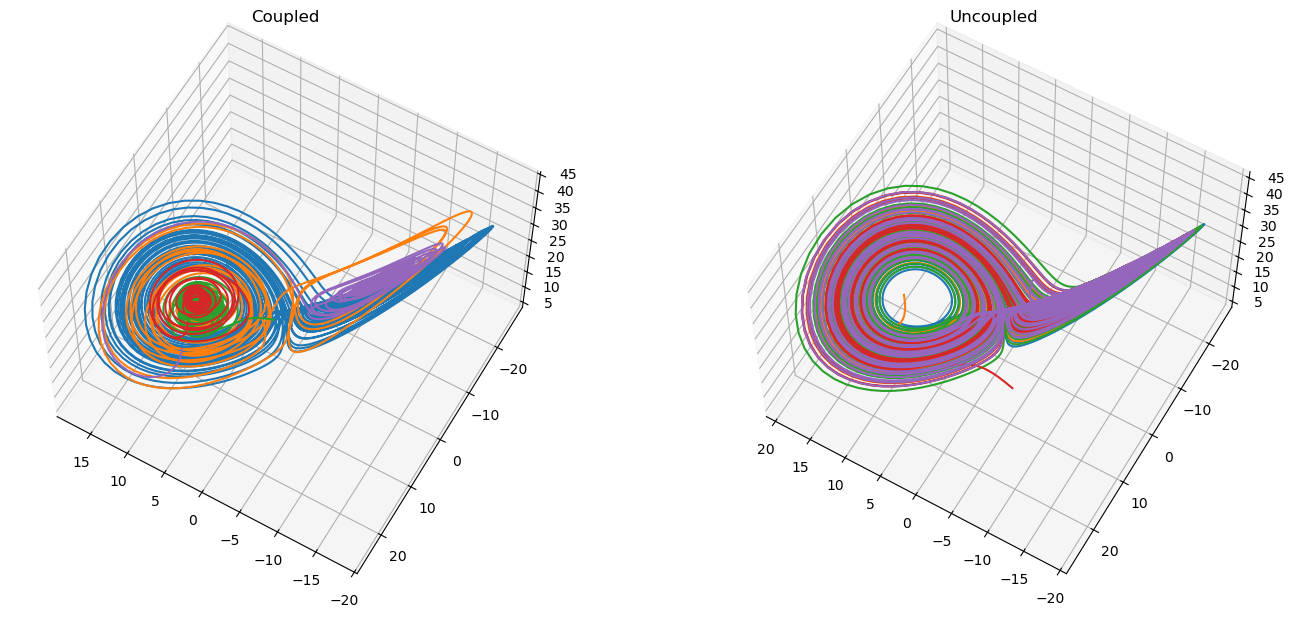

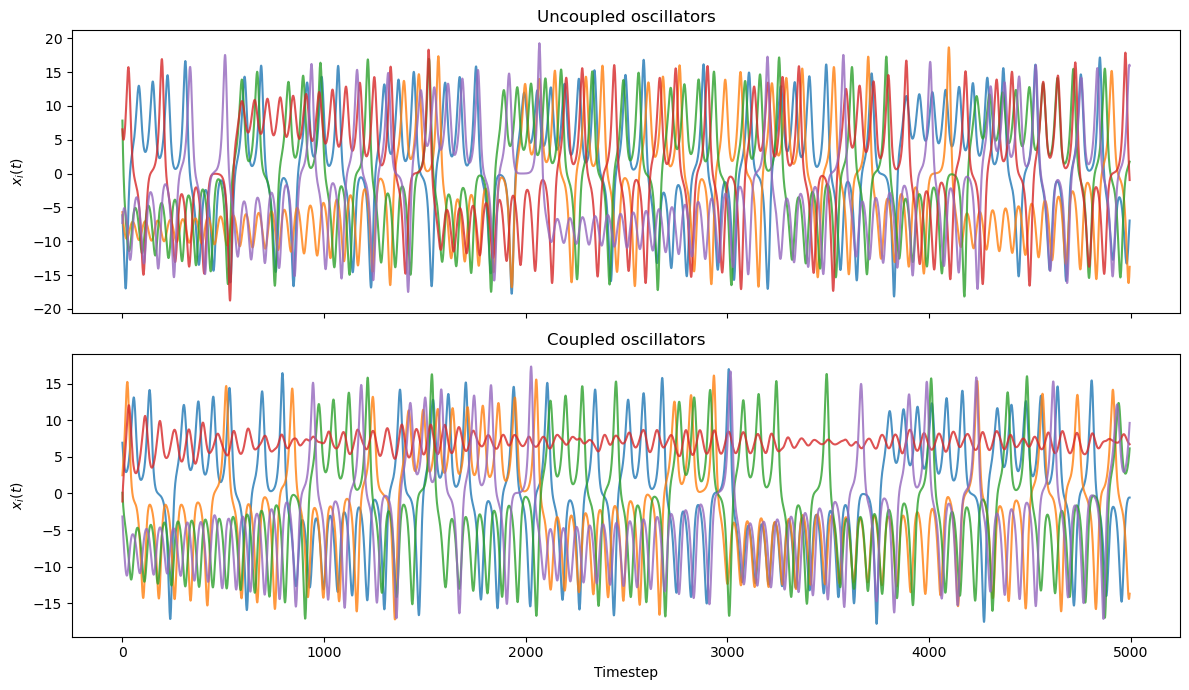

In [6]:
import matplotlib.pyplot as plt

adj_matrix = make_adjacency(100, 3)

coupled_data, coupled_derivatives = make_data(
    num_samples=timesteps,
    adjacency=adj_matrix,
    coupling=0.8,
)

uncoupled_data, uncoupled_derivatives = make_data(
    num_samples=timesteps,
    adjacency=adj_matrix,
    coupling=0.0,
)

# axs has shape (2, 5)
fig, axs = plt.subplots(1, 2, figsize=(15, 6), subplot_kw={"projection": "3d"})
num_nodes = 5
for node in range(num_nodes):
    axs[0].plot(
        coupled_data[:, node * 5, 0],
        coupled_data[:, node * 5, 1],
        coupled_data[:, node * 5, 2],
    )
axs[0].set_title(f"Coupled")
axs[0].view_init(elev=60, azim=120)
for node in range(num_nodes):
    axs[1].plot(
        uncoupled_data[:, node * 5, 0],
        uncoupled_data[:, node * 5, 1],
        uncoupled_data[:, node * 5, 2],
    )
axs[1].set_title(f"Uncoupled")
axs[1].view_init(elev=60, azim=120)

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for node in range(5):
    axs[0].plot(uncoupled_data[:, node, 0], alpha=0.8)

for node in range(5):
    axs[1].plot(coupled_data[:, node, 0], alpha=0.8)

axs[0].set_title("Uncoupled oscillators")
axs[1].set_title("Coupled oscillators")

axs[0].set_ylabel("$x_i(t)$")
axs[1].set_ylabel("$x_i(t)$")
axs[1].set_xlabel("Timestep")

plt.tight_layout()
plt.show()